In [25]:
import logging
import math

import tsplib95

logging.basicConfig(level=logging.INFO)

import numpy as np

graph = tsplib95.load('data/att48.tsp')
n = graph.dimension

dist_mtx = np.zeros((n, n), dtype=np.float64)

for i in range(n):
    for j in range(n):
        if i == j:
            dist_mtx[i, j] = math.inf
        else:
            dist_mtx[i, j] = graph.get_weight(i + 1, j + 1)


coords = np.array(
    [graph.node_coords[i + 1] for i in range(n)], dtype=np.float64
)

# Importante colocar diagonal como infinito (se não vai dar pau no DP)

In [27]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]   # COMP_EV_GROUP_F
src_path = project_root / "src"

sys.path.insert(0, str(src_path))

print(src_path)

c:\Users\vinic\comp_ev_group_F\src


In [28]:
from TP.problems.vrp.utils.problem_data import VRPProblemData

problem_instance = VRPProblemData(
    n_vehicles=5, depot_node=0, dist_mtx=dist_mtx
)

In [29]:
from TP.core.logging.observer import BestFitnessLogger
from TP.core.logging.progress import EALogger
from TP.core.multiobjective.selection.parents.operators import CrowdTournament
from TP.core.multiobjective.selection.survivors.operators import (
    NonDominanceOrdering,
)
from TP.core.variation.mutation import RSM
from TP.problems.tsp.variation.recombination import SCX
from TP.problems.vrp.NSGAII_interface import VRPNSGAIIOrchestrator

pop_size = 140
tournament_size = 7

data_logger = BestFitnessLogger()
process_logger = EALogger()
parent_selector = CrowdTournament(tournament_size=tournament_size)
survivor_selector = NonDominanceOrdering()
recombinator = SCX(dist_mtx=problem_instance.dist_mtx)
mutation_operator = RSM()


orchestrator = VRPNSGAIIOrchestrator(
    problem_instance=problem_instance,
    survivor_selector=survivor_selector,
    mutation_operator=mutation_operator,
    recombinator=recombinator,
    pop_size=pop_size,
    parent_selector=parent_selector,
    max_generations=600,
    observers=[data_logger],
    loggers=[process_logger],
    p_c=0.8,
    p_m=0.25,
    p_ls=0.15,
)
out = orchestrator.run()

INFO:TP.core.logging.progress:EA started | population_size=140
INFO:TP.core.logging.progress:Generation 100 | Best front size=3 | Pop Size=140
INFO:TP.core.logging.progress:Generation 200 | Best front size=2 | Pop Size=140
INFO:TP.core.logging.progress:Generation 300 | Best front size=7 | Pop Size=140
INFO:TP.core.logging.progress:Generation 400 | Best front size=7 | Pop Size=140
INFO:TP.core.logging.progress:Generation 500 | Best front size=7 | Pop Size=140
INFO:TP.core.logging.progress:Generation 600 | Best front size=7 | Pop Size=140
INFO:TP.core.logging.progress:EA finished | generations=601 | best front size=7.00000 | feasible=False


In [30]:
import numpy as np
import plotly.graph_objects as go


def plot_last_generations(data_logger, n_last=5):
    generations = data_logger.generations
    fronts = data_logger.best_fitness

    # pega últimas N
    selected_gens = generations[-n_last:]
    selected_fronts = fronts[-n_last:]

    # paleta de cores (fixa e bem distinta)
    colors = [
        '#1f77b4',  # azul
        '#ff7f0e',  # laranja
        '#2ca02c',  # verde
        '#d62728',  # vermelho
        '#9467bd',  # roxo
        '#8c564b',  # marrom
        '#e377c2',  # rosa
        '#7f7f7f',  # cinza
    ]

    fig = go.Figure()

    # limites globais (opcional, ajuda consistência visual)
    all_x = []
    all_y = []

    for front in selected_fronts:
        all_x.extend([f.total_distance.value for f in front])
        all_y.extend([f.max_imbalance.value for f in front])

    x_range = [min(all_x), max(all_x)]
    y_range = [min(all_y), max(all_y)]

    # adiciona cada geração como um trace
    for i, (gen, front) in enumerate(zip(selected_gens, selected_fronts)):
        x = [f.total_distance.value for f in front]
        y = [f.max_imbalance.value for f in front]

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode='markers',
                marker=dict(
                    size=10,
                    color=colors[i % len(colors)],
                ),
                name=f'Gen {gen}',
            )
        )

    fig.update_layout(
        title=f'Pareto Front - Last {n_last} Generations',
        xaxis_title='Total Distance',
        yaxis_title='Max Imbalance',
        xaxis=dict(range=x_range),
        yaxis=dict(range=y_range),
        legend=dict(title='Generation'),
    )

    fig.show()

In [31]:
plot_last_generations(data_logger, n_last=5)

In [32]:
import numpy as np


def sample_front(front, n_samples=15):
    """Sampling por quantis para manter distribuição"""
    if len(front) <= n_samples:
        return front

    pts = np.array([
        [f.fitness.total_distance.value, f.fitness.max_imbalance.value]
        for f in front
    ])

    x = pts[:, 0]

    # ordenar por eixo X (melhora visual da fronteira)
    sort_idx = np.argsort(x)

    # pegar índices igualmente espaçados
    sample_idx = np.linspace(0, len(front) - 1, n_samples, dtype=int)

    selected_idx = sort_idx[sample_idx]

    return [front[i] for i in selected_idx]


def plot_all_fronts(state, n_samples=15):
    """
    Plota todos os fronts da última geração usando EAState
    """

    if state.fronts is None:
        raise ValueError('State does not contain fronts.')

    fig = go.Figure()

    # paleta de cores
    colors = [
        '#1f77b4',
        '#ff7f0e',
        '#2ca02c',
        '#d62728',
        '#9467bd',
        '#8c564b',
        '#e377c2',
        '#7f7f7f',
        '#bcbd22',
        '#17becf',
    ]

    for i, front in enumerate(state.fronts):
        if len(front) == 0:
            continue

        sampled = sample_front(front, n_samples=n_samples)

        # ordenar para visualização mais suave
        sampled = sorted(
            sampled, key=lambda ind: ind.fitness.total_distance.value
        )

        x = [ind.fitness.total_distance.value for ind in sampled]
        y = [ind.fitness.max_imbalance.value for ind in sampled]

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode='markers+lines',
                marker=dict(size=8),
                line=dict(width=2),
                name=f'Front {i} (n={len(front)})',
            )
        )

    fig.update_layout(
        title=f'Última geração – Todos os Pareto fronts (sample={n_samples})',
        xaxis_title='Total Distance',
        yaxis_title='Max Imbalance',
        legend_title='Front',
    )

    fig.show()

In [33]:
plot_all_fronts(out, n_samples=15)

## 🔹Tempo de Convergência

## 🔹Hipervolume (HV)

In [38]:

from pymoo.indicators.hv import HV

front = data_logger.best_fitness[-1]

F = np.array([
    [f.total_distance.value, f.max_imbalance.value]
    for f in front
])

print(F.shape)
F[:5]


# HV maior -> melhor convergência + melhor diversidade.
# HV menor -> fronteira mais distante do ótimo ou pouco espalhada.

# ponto de referência pior que todas as soluções
ref_point = F.max(axis=0) * 1.1
hv = HV(ref_point=ref_point)
hv_value = hv(F)

print(f"Hipervolume = {hv_value:.4f}")

(7, 2)
Hipervolume = 129995848.2000


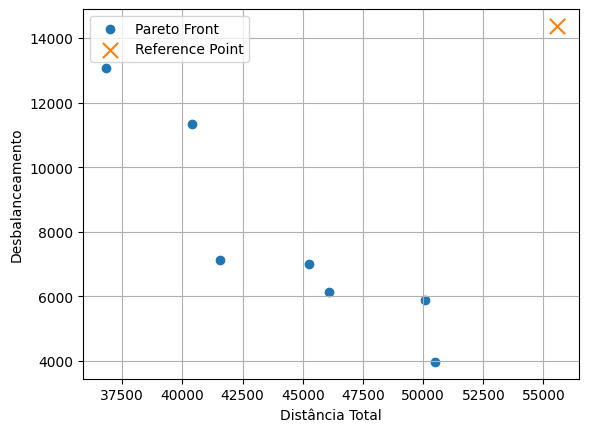

In [39]:
import matplotlib.pyplot as plt

plt.scatter(F[:,0], F[:,1], label="Pareto Front")
plt.scatter(
    ref_point[0],
    ref_point[1],
    marker="x",
    s=120,
    label="Reference Point"
)

plt.xlabel("Distância Total")
plt.ylabel("Desbalanceamento")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
print(F)
print(ref_point)
# trade off claro:
#  menor distância -> grande desbalanceamento;
#  maior equilíbrio -> maior distância.

[[36814. 13064.]
 [46084.  6146.]
 [50097.  5884.]
 [45267.  7012.]
 [41552.  7119.]
 [50495.  3972.]
 [40408. 11345.]]
[55544.5 14370.4]


## 🔹Generational Distance (GD):

In [49]:
# GD usando uma fronteira de referência construída pela união das fronteiras de todas as gerações. 
# Depois vale rodar 30 vezes, juntar todas as soluções não dominadas encontradas e extrair a fronteira não dominada global;

from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Junta todas as soluções observadas durante a execução
all_points = []
for front in data_logger.best_fitness:

    for f in front:
        all_points.append([f.total_distance.value, f.max_imbalance.value])

all_points = np.array(all_points)

print("Total de pontos coletados:", len(all_points))

nds = NonDominatedSorting()

ref_idx = nds.do(all_points, only_non_dominated_front=True)

F_ref = all_points[ref_idx]

print("Tamanho da fronteira de referência:", len(F_ref))

Total de pontos coletados: 33
Tamanho da fronteira de referência: 12


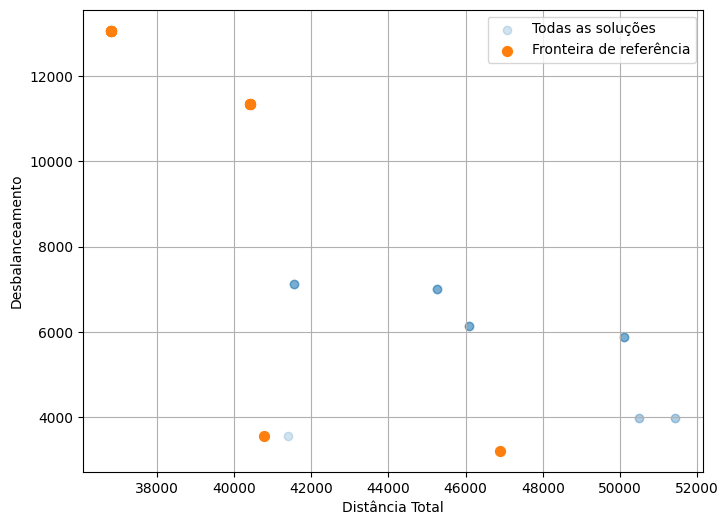

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(all_points[:,0], all_points[:,1], alpha=0.2, label="Todas as soluções")

plt.scatter( F_ref[:,0], F_ref[:,1], s=50, label="Fronteira de referência")

plt.xlabel("Distância Total")
plt.ylabel("Desbalanceamento")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from pymoo.indicators.gd import GD

# Fronteira final
front_final = data_logger.best_fitness[-1]
F = np.array([
    [f.total_distance.value, f.max_imbalance.value]
    for f in front_final
])

# Normalização usando a fronteira de referência
mins = F_ref.min(axis=0)
maxs = F_ref.max(axis=0)

# Evita divisão por zero caso algum objetivo seja constante
ranges = np.where(maxs - mins == 0, 1, maxs - mins)

F_ref_norm = (F_ref - mins) / ranges
F_norm = (F - mins) / ranges

# GD original
gd_value = GD(F_ref)(F)

# GD normalizado
gd_norm_value = GD(F_ref_norm)(F_norm)

print(f"GD = {gd_value:.6f}")
print(f"GD normalizado = {gd_norm_value:.6f}")

# em média, as soluções da sua fronteira final estão a aproximadamente x% da escala normalizada dos objetivos da fronteira de referência.

GD = 2668.459872
GD normalizado = 0.268535


## 🔹Inverted Generational Distance (IGD)

In [51]:
# IGD usando uma fronteira de referência construída pela união das fronteiras de todas as gerações. 
# Depois vale rodar 30 vezes, juntar todas as soluções não dominadas encontradas e extrair a fronteira não dominada global;
from pymoo.indicators.igd import IGD

# IGD original
igd_value = IGD(F_ref)(F)

# IGD normalizado
igd_norm_value = IGD(F_ref_norm)(F_norm)

print(f"IGD = {igd_value:.6f}")
print(f"IGD normalizado = {igd_norm_value:.6f}")

IGD = 558.175465
IGD normalizado = 0.056582


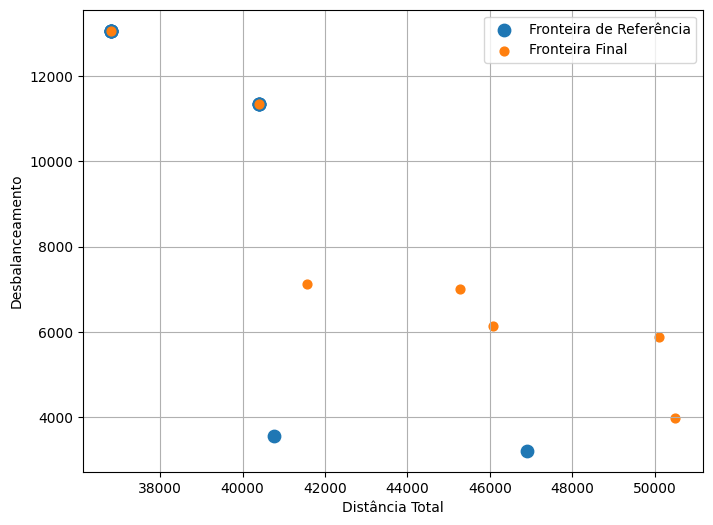

In [52]:
plt.figure(figsize=(8,6))

plt.scatter( F_ref[:,0], F_ref[:,1], s=80, label="Fronteira de Referência")

plt.scatter(F[:,0], F[:,1], s=40, label="Fronteira Final")

plt.xlabel("Distância Total")
plt.ylabel("Desbalanceamento")
plt.legend()
plt.grid(True)
plt.show()